# BC2410/BC2411 — Resume Shortlisting Optimisation
## Notebook 2: MILP Formulation, Baselines & Results

**Group Project — Prescriptive Analytics: From Data to Decisions**

---

### Design: Raw Signals → Per-Job Normalisation → MILP

Each matching signal (TF-IDF, BM25, skill overlap, etc.) has a different natural scale. TF-IDF cosine between a resume and a job description rarely exceeds 0.2, while BM25 can reach 1.0. Combining them directly produces misleadingly low scores.

**Fix**: We apply **per-job min-max normalisation** to each signal. For job *j*, each signal is scaled so the best-matching resume gets 1.0 and the worst gets 0.0. This is standard in information retrieval (per-query normalisation) and ensures that:
- All signals contribute equally when weights are equal
- Composite scores are interpretable on a 0–1 scale
- The quality floor constraint works as intended

## 1. Setup & Load Data

In [3]:
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gurobipy as gp
from gurobipy import GRB

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
OUT_DIR  = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ── Load Notebook 1 outputs ──
pair_df   = pd.read_csv(DATA_DIR / "pair_features.csv")
resume_df = pd.read_csv(DATA_DIR / "resumes_milp_sample.csv")
job_df    = pd.read_csv(DATA_DIR / "jobs_milp_sample.csv")

for col in ["skill_set", "required_skills"]:
    for df in [resume_df, job_df]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])
if "required_skill_weights" in job_df.columns:
    job_df["required_skill_weights"] = job_df["required_skill_weights"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else {})

print(f"Pairs: {len(pair_df):,}  |  Resumes: {len(resume_df)}  |  Jobs: {len(job_df)}")

Pairs: 45,000  |  Resumes: 500  |  Jobs: 90


## 2. Per-Job Signal Normalisation

### Why this matters

Raw signal ranges from Notebook 1:

| Signal | Mean | Max | Problem |
|--------|------|-----|---------|
| `tfidf_sim` | 0.033 | 0.21 | Very compressed — top candidate barely different from median |
| `bm25_sim` | 0.36 | 1.0 | Good range but dominates TF-IDF |
| `skill_jaccard` | 0.09 | 1.0 | Good range |
| `weighted_required_hit` | 0.18 | 1.0 | Good range |
| `exp_gap` | 0.58 | 9.0 | Years — not on 0–1 scale |
| `degree_gap` | 0.82 | 4.0 | Levels — not on 0–1 scale |

After per-job min-max normalisation, **every signal is on [0, 1] for each job**, so:
- Weights are directly interpretable (0.25 means "this signal is 25% of the total")
- The best resume for a given job always scores 1.0 on each signal
- Penalties are also normalised to [0, 1]

In [6]:
# ── Per-job min-max normalisation ──
SIGNALS_TO_NORMALISE = {
    # Positive signals (higher = better match)
    "tfidf_sim": "pos",
    "bm25_sim": "pos",
    "skill_overlap_jaccard": "pos",
    "weighted_required_hit": "pos",
    # Negative signals (higher = worse, will be inverted to "lower gap = better")
    "exp_gap": "neg",
    "degree_gap": "neg",
    "length_penalty": "neg",
}

norm_df = pair_df.copy()

for signal, direction in SIGNALS_TO_NORMALISE.items():
    col_norm = f"{signal}_norm"
    
    # Min-max per job
    grouped = norm_df.groupby("job_id")[signal]
    mins = grouped.transform("min")
    maxs = grouped.transform("max")
    rng = maxs - mins
    
    # Normalise to [0, 1]; if range is 0, set to 0.5
    norm_df[col_norm] = np.where(rng > 1e-9, (norm_df[signal] - mins) / rng, 0.5)
    
    # For negative signals, invert so 0 gap → 1.0 (good) and max gap → 0.0 (bad)
    if direction == "neg":
        norm_df[col_norm] = 1.0 - norm_df[col_norm]

# Verify normalisation
print("Per-job normalised signal ranges:")
for signal in SIGNALS_TO_NORMALISE:
    col = f"{signal}_norm"
    print(f"  {col:35s}  mean={norm_df[col].mean():.3f}  min={norm_df[col].min():.3f}  max={norm_df[col].max():.3f}")

Per-job normalised signal ranges:
  tfidf_sim_norm                       mean=0.324  min=0.000  max=1.000
  bm25_sim_norm                        mean=0.362  min=0.000  max=1.000
  skill_overlap_jaccard_norm           mean=0.205  min=0.000  max=1.000
  weighted_required_hit_norm           mean=0.208  min=0.000  max=1.000
  exp_gap_norm                         mean=0.820  min=0.000  max=1.000
  degree_gap_norm                      mean=0.658  min=0.000  max=1.000
  length_penalty_norm                  mean=0.952  min=0.000  max=1.000


## 3. MILP Configuration

### 3.1 Structural Parameters

In [8]:
K_SHORTLIST         = 5
MAX_CANDIDATE_JOBS  = 2
REVIEW_BUDGET_MIN   = 65.0    # calibrated from NB1: median ~10 min/resume × 5 + buffer
MAX_CLUSTER_PER_JOB = 1
MIN_AVG_SCORE_FLOOR = 0.40    # now meaningful on the 0–1 normalised scale
GUROBI_TIME_LIMIT   = 600
GUROBI_MIP_GAP      = 0.001   # stop when within 0.1% of optimal

print(f"Budget: {REVIEW_BUDGET_MIN} min  |  Quality floor: {MIN_AVG_SCORE_FLOOR}  |  Solver limit: {GUROBI_TIME_LIMIT}s")

Budget: 65.0 min  |  Quality floor: 0.4  |  Solver limit: 600s


### 3.2 Objective Coefficients

Now that all signals are on [0, 1], these weights are directly interpretable as **relative importance**.

In [10]:
DEFAULT_CONFIG = {
    "w_tfidf":    0.15,   # lexical similarity
    "w_bm25":     0.15,   # term-frequency relevance
    "w_skill":    0.25,   # skill set overlap
    "w_coverage": 0.20,   # scarcity-weighted required skill hits
    "w_exp":      0.10,   # experience match (inverted gap)
    "w_deg":      0.05,   # degree match (inverted gap)
    "w_length":   0.05,   # resume length match (inverted penalty)
    "w_skill_cov": 0.12,  # shortlist-level coverage bonus
    "w_underfill": 0.35,  # underfill penalty per slot
    "w_quality":   0.25,  # quality shortfall penalty
}

# Verify positive weights sum to ~1
pos_sum = sum(DEFAULT_CONFIG[k] for k in ["w_tfidf","w_bm25","w_skill","w_coverage","w_exp","w_deg","w_length"])
print(f"Per-pair signal weights sum: {pos_sum:.2f} (should be ~1.0)")
for k, v in DEFAULT_CONFIG.items():
    print(f"  {k:16s} = {v:.2f}")

Per-pair signal weights sum: 0.95 (should be ~1.0)
  w_tfidf          = 0.15
  w_bm25           = 0.15
  w_skill          = 0.25
  w_coverage       = 0.20
  w_exp            = 0.10
  w_deg            = 0.05
  w_length         = 0.05
  w_skill_cov      = 0.12
  w_underfill      = 0.35
  w_quality        = 0.25


## 4. Build Lookup Tables

In [12]:
# ── Normalised pair-level lookups ──
n_tfidf = {}; n_bm25 = {}; n_skill = {}; n_cov = {}
n_exp = {}; n_deg = {}; n_length = {}

for _, row in norm_df.iterrows():
    key = (int(row["resume_id"]), int(row["job_id"]))
    n_tfidf[key]  = float(row["tfidf_sim_norm"])
    n_bm25[key]   = float(row["bm25_sim_norm"])
    n_skill[key]  = float(row["skill_overlap_jaccard_norm"])
    n_cov[key]    = float(row["weighted_required_hit_norm"])
    n_exp[key]    = float(row["exp_gap_norm"])        # already inverted: 1 = no gap
    n_deg[key]    = float(row["degree_gap_norm"])      # already inverted
    n_length[key] = float(row["length_penalty_norm"])  # already inverted

# ── Resume-level ──
review_time = {}; cluster_of = {}
for _, r in resume_df.iterrows():
    rid = int(r["resume_id"])
    review_time[rid] = float(r["review_minutes_capped"])
    cluster_of[rid]  = int(r["redundancy_cluster"])

# ── Job-level ──
job_req_skills = {}; skill_weight = {}; skill_has = {}
for _, row in job_df.iterrows():
    j = int(row["job_id"])
    req = row["required_skills"]
    weights = row["required_skill_weights"]
    job_req_skills[j] = set(req)
    for s in req:
        skill_weight[(j, s)] = float(weights.get(s, 1.0))

for _, row in pair_df.iterrows():
    i, j = int(row["resume_id"]), int(row["job_id"])
    if j in job_req_skills:
        r_skills = set(resume_df.loc[resume_df["resume_id"] == i, "skill_set"].iloc[0])
        for s in job_req_skills[j]:
            skill_has[(i, j, s)] = 1 if s in r_skills else 0

cluster_members = {}
for rid, cid in cluster_of.items():
    cluster_members.setdefault(cid, []).append(rid)

ALL_RESUMES = sorted(resume_df["resume_id"].unique())
ALL_JOBS    = sorted(job_df["job_id"].unique())
ALL_PAIRS   = list(n_tfidf.keys())

print(f"Pairs: {len(ALL_PAIRS):,}  |  Clusters: {len(cluster_members)} ({sum(1 for v in cluster_members.values() if len(v)>1)} multi-resume)")

Pairs: 45,000  |  Clusters: 479 (13 multi-resume)


## 5. MILP Solver

### 5.1 Core Solver Function

All signals enter the objective **already normalised to [0, 1]**, so positive terms are rewards and all coefficients are directly interpretable.

https://chatgpt.com/share/69d3fdef-edf8-83a0-a27c-85c9e2c09fb6

In [14]:
def pair_quality(i, j, w):
    """Compute normalised pair quality score (0–1 scale)."""
    return (w["w_tfidf"]  * n_tfidf[(i,j)]
          + w["w_bm25"]   * n_bm25[(i,j)]
          + w["w_skill"]  * n_skill[(i,j)]
          + w["w_coverage"]* n_cov[(i,j)]
          + w["w_exp"]    * n_exp[(i,j)]
          + w["w_deg"]    * n_deg[(i,j)]
          + w["w_length"] * n_length[(i,j)])


def solve_milp(config: dict, verbose: bool = True,
               budget: float = None, floor: float = None) -> dict:
    """
    Build and solve the MILP.
    All per-pair signals are normalised to [0,1], so the objective
    and quality floor operate on the same interpretable scale.
    """

    w = config
    B = budget or REVIEW_BUDGET_MIN
    F = floor or MIN_AVG_SCORE_FLOOR
    t0 = time.perf_counter()

    m = gp.Model("ResumeShortlisting")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = GUROBI_TIME_LIMIT
    m.Params.MIPGap = GUROBI_MIP_GAP

    # ── Variables ──
    x = {(i,j): m.addVar(vtype=GRB.BINARY) for (i,j) in ALL_PAIRS}
    u = {j: m.addVar(lb=0, ub=K_SHORTLIST) for j in ALL_JOBS}
    y = {}
    for j in ALL_JOBS:
        for s in job_req_skills.get(j, []):
            y[j, s] = m.addVar(vtype=GRB.BINARY)
    q = {j: m.addVar(lb=0) for j in ALL_JOBS}
    m.update()

    # ── Objective ──
    obj = gp.LinExpr()

    # Per-pair quality (all signals normalised, all positive)
    for (i, j), var in x.items():
        obj += pair_quality(i, j, w) * var

    # Shortlist-level skill coverage bonus
    for (j, s), var in y.items():
        obj += w["w_skill_cov"] * skill_weight.get((j, s), 1.0) * var

    # Penalties
    for j in ALL_JOBS:
        obj -= w["w_underfill"] * u[j]
        obj -= w["w_quality"]   * q[j]

    m.setObjective(obj, GRB.MAXIMIZE)

    # ── C1: Shortlist size ──
    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(x[i,j] for i in ALL_RESUMES if (i,j) in x) + u[j] == K_SHORTLIST)

    # ── C2: Review time budget ──
    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(review_time[i] * x[i,j] for i in ALL_RESUMES if (i,j) in x) <= B)

    # ── C3: Candidate exposure cap ──
    for i in ALL_RESUMES:
        m.addConstr(gp.quicksum(x[i,j] for j in ALL_JOBS if (i,j) in x) <= MAX_CANDIDATE_JOBS)

    # ── C4: Skill coverage linking ──
    for j in ALL_JOBS:
        for s in job_req_skills.get(j, []):
            if (j, s) in y:
                m.addConstr(y[j,s] <= gp.quicksum(
                    skill_has.get((i,j,s), 0) * x[i,j] for i in ALL_RESUMES if (i,j) in x))

    # ── C5: Minimum average quality (soft, on normalised 0–1 scale) ──
    for j in ALL_JOBS:
        m.addConstr(
            gp.quicksum(pair_quality(i, j, w) * x[i,j] for i in ALL_RESUMES if (i,j) in x) + q[j]
            >= F * (K_SHORTLIST - u[j])
        )

    # ── C6: Anti-redundancy ──
    for j in ALL_JOBS:
        for cid, members in cluster_members.items():
            if len(members) > 1:
                eligible = [i for i in members if (i,j) in x]
                if len(eligible) > 1:
                    m.addConstr(gp.quicksum(x[i,j] for i in eligible) <= MAX_CLUSTER_PER_JOB)

    m.optimize()
    solve_time = time.perf_counter() - t0

    if m.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount > 0:
        selected = [(i, j) for (i, j), var in x.items() if var.X > 0.5]

        x_df = pd.DataFrame([
            {
                "resume_id": i,
                "job_id": j,
                "x_value": float(var.X),
                "selected": int(var.X > 0.5),
                "pair_quality": float(pair_quality(i, j, w)),
                "review_minutes": float(review_time[i]),
                "redundancy_cluster": int(cluster_of[i]),
            }
            for (i, j), var in x.items()
        ])

        u_df = pd.DataFrame([
            {
                "job_id": j,
                "u_value": float(u[j].X),
                "filled_slots": float(K_SHORTLIST - u[j].X),
            }
            for j in ALL_JOBS
        ])

        q_df = pd.DataFrame([
            {
                "job_id": j,
                "q_value": float(q[j].X),
            }
            for j in ALL_JOBS
        ])

        y_df = pd.DataFrame([
            {
                "job_id": j,
                "skill": s,
                "y_value": float(var.X),
                "skill_weight": float(skill_weight.get((j, s), 1.0)),
            }
            for (j, s), var in y.items()
        ])

        return {
            "selected": selected,
            "obj_val": m.ObjVal,
            "status": m.Status,
            "solve_time": solve_time,
            "config": config,
            "gap": m.MIPGap if hasattr(m, "MIPGap") else None,
            "x_df": x_df,
            "u_df": u_df,
            "q_df": q_df,
            "y_df": y_df,
        }

### 5.2 Evaluation Function

In [16]:
def evaluate(selected_pairs, label="Method", config=None):
    """Compute operational metrics using normalised signals."""
    w = config or DEFAULT_CONFIG
    sel = pd.DataFrame(selected_pairs, columns=["resume_id", "job_id"])
    sel = sel.merge(norm_df, on=["resume_id", "job_id"], how="left")

    job_rows = []
    for j in ALL_JOBS:
        js = sel[sel["job_id"] == j]
        n = len(js)

        # Per-pair normalised quality score
        if n > 0:
            scores = []
            for _, row in js.iterrows():
                key = (int(row["resume_id"]), j)
                scores.append(pair_quality(key[0], key[1], w))
            mean_score = np.mean(scores)
        else:
            mean_score = 0.0

        # Skill coverage
        req = set(job_df.loc[job_df["job_id"] == j, "required_skills"].iloc[0])
        covered = set()
        for _, row in js.iterrows():
            r_sk = set(resume_df.loc[resume_df["resume_id"] == int(row["resume_id"]), "skill_set"].iloc[0])
            covered |= (r_sk & req)
        cov = len(covered) / max(len(req), 1)
        t_min = js["review_minutes_capped"].sum() if n > 0 else 0.0

        job_rows.append({"n": n, "score": mean_score, "coverage": cov,
                         "time": t_min, "cov_per_min": cov / max(t_min, 0.01),
                         "underfilled": int(n < K_SHORTLIST)})

    jm = pd.DataFrame(job_rows)
    unique = sel["resume_id"].nunique()

    return {
        "method": label, "total_selected": len(sel),
        "mean_match_score": jm["score"].mean(),
        "mean_coverage": jm["coverage"].mean(),
        "mean_cov_per_min": jm["cov_per_min"].mean(),
        "mean_review_min": jm["time"].mean(),
        "novelty_ratio": unique / max(len(sel), 1),
        "underfilled_jobs": int(jm["underfilled"].sum()),
    }

### 5.3 Run Default MILP

In [18]:
print("Solving MILP with default config …")
milp_result = solve_milp(DEFAULT_CONFIG, verbose=True)
print(f"\nSelected: {len(milp_result['selected'])} | Obj: {milp_result['obj_val']:.2f} | "
      f"Gap: {milp_result.get('gap','N/A')} | Time: {milp_result['solve_time']:.1f}s")

Solving MILP with default config …
Set parameter Username
Set parameter LicenseID to value 2769976
Academic license - for non-commercial use only - expires 2027-01-26
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.001
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 255H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.001

Optimize a model with 2326 rows, 45566 columns and 220785 nonzeros (Max)
Model fingerprint: 0x33960592
Model has 45566 linear objective coefficients
Variable types: 180 continuous, 45386 integer (45386 binary)
Coefficient statistics:
  Matrix range     [6e-02, 3e+01]
  Objective range  [6e-02, 9e-01]
  Bounds range     [1e+00, 5e+00]
  RHS range        [1e+00, 7e+01]

Found heuristic solution: objective 181.3241437
Presolve rem

## 6. Automated Coefficient Sweep

In [20]:
SWEEP_CONFIGS = {
    "default": (DEFAULT_CONFIG, REVIEW_BUDGET_MIN, MIN_AVG_SCORE_FLOOR),

    "coverage_focus": ({
        **DEFAULT_CONFIG, "w_skill": 0.30, "w_coverage": 0.25, "w_skill_cov": 0.18,
        "w_tfidf": 0.10, "w_bm25": 0.10,
    }, REVIEW_BUDGET_MIN, 0.35),

    "score_focus": ({
        **DEFAULT_CONFIG, "w_tfidf": 0.22, "w_bm25": 0.20, "w_skill": 0.20,
        "w_coverage": 0.15, "w_skill_cov": 0.06,
    }, REVIEW_BUDGET_MIN, 0.45),

    "exp_strict": ({
        **DEFAULT_CONFIG, "w_exp": 0.20, "w_deg": 0.10, "w_skill": 0.20, "w_coverage": 0.15,
    }, REVIEW_BUDGET_MIN, 0.40),

    "tight_budget": (DEFAULT_CONFIG, 45.0, 0.35),

    "balanced": ({
        "w_tfidf": 0.15, "w_bm25": 0.15, "w_skill": 0.20, "w_coverage": 0.18,
        "w_exp": 0.12, "w_deg": 0.06, "w_length": 0.04,
        "w_skill_cov": 0.10, "w_underfill": 0.30, "w_quality": 0.22,
    }, REVIEW_BUDGET_MIN, 0.38),
}

sweep_rows = []
for name, (cfg, budget, floor) in SWEEP_CONFIGS.items():
    print(f"Running: {name} (budget={budget}, floor={floor}) …")
    result = solve_milp(cfg, verbose=False, budget=budget, floor=floor)
    metrics = evaluate(result["selected"], label=name, config=cfg)
    underfill_rate = metrics["underfilled_jobs"] / len(ALL_JOBS)
    meta = metrics["mean_match_score"] * metrics["mean_coverage"] * (1 - underfill_rate)
    sweep_rows.append({
        "config": name, "budget": budget, "floor": floor,
        **metrics, "obj_val": result["obj_val"],
        "solve_time": result["solve_time"], "gap": result.get("gap"),
        "meta_score": meta,
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values("meta_score", ascending=False)
print("\n" + "═"*80)
display(sweep_df[["config","mean_match_score","mean_coverage","novelty_ratio",
                  "underfilled_jobs","mean_review_min","meta_score"]])

best_name = sweep_df.iloc[0]["config"]
BEST_CONFIG, BEST_BUDGET, BEST_FLOOR = SWEEP_CONFIGS[best_name]
print(f"\nBest: {best_name} (meta={sweep_df.iloc[0]['meta_score']:.4f})")

Running: default (budget=65.0, floor=0.4) …
Running: coverage_focus (budget=65.0, floor=0.35) …
Running: score_focus (budget=65.0, floor=0.45) …
Running: exp_strict (budget=65.0, floor=0.4) …
Running: tight_budget (budget=45.0, floor=0.35) …
Running: balanced (budget=65.0, floor=0.38) …

════════════════════════════════════════════════════════════════════════════════


,config,mean_match_score,mean_coverage,novelty_ratio,underfilled_jobs,mean_review_min,meta_score
3,exp_strict,0.7396,0.9578,0.6111,0,61.6300,0.7083
1,coverage_focus,0.6880,0.9578,0.6289,0,59.3304,0.6589
2,score_focus,0.6898,0.9533,0.6089,0,61.5502,0.6576
0,default,0.6789,0.9578,0.6156,0,60.8750,0.6503
5,balanced,0.6466,0.9578,0.6356,0,61.6764,0.6193
4,tight_budget,0.6345,0.9511,0.5978,0,43.5551,0.6035



Best: exp_strict (meta=0.7083)


## 7. Baselines

In [22]:
def greedy_baseline(pair_df_norm, config=None, k=K_SHORTLIST,
                    budget=REVIEW_BUDGET_MIN, max_exposure=MAX_CANDIDATE_JOBS):
    """Greedy shortlisting using normalised scores, with constraints."""
    w = config or DEFAULT_CONFIG

    # Pre-compute normalised scores
    scores = {}
    for (i,j) in ALL_PAIRS:
        scores[(i,j)] = pair_quality(i, j, w)

    exposure = Counter()
    selected = []

    for j in sorted(set(jj for (_,jj) in ALL_PAIRS)):
        candidates = [(scores[(i,j)], i) for (ii,jj) in ALL_PAIRS if jj == j for i in [ii]]
        # Deduplicate and sort
        seen = set()
        unique_cands = []
        for s, i in sorted(candidates, reverse=True):
            if i not in seen:
                unique_cands.append((s, i))
                seen.add(i)

        shortlist, t_used, clusters_used = [], 0.0, set()
        for s, i in unique_cands:
            if len(shortlist) >= k: break
            t = review_time[i]
            c = cluster_of[i]
            if exposure[i] >= max_exposure or t_used + t > budget or c in clusters_used:
                continue
            shortlist.append((i, j)); exposure[i] += 1; t_used += t; clusters_used.add(c)
        selected.extend(shortlist)
    return selected

greedy_selected = greedy_baseline(norm_df, DEFAULT_CONFIG, budget=BEST_BUDGET)
print(f"Greedy: {len(greedy_selected)} pairs")

Greedy: 383 pairs


In [23]:
def scoreonly_baseline(config=None, k=K_SHORTLIST):
    """Top-k by score per job, no constraints."""
    w = config or DEFAULT_CONFIG
    selected = []
    for j in ALL_JOBS:
        cands = [(pair_quality(i, j, w), i) for i in ALL_RESUMES if (i,j) in n_tfidf]
        cands.sort(reverse=True)
        selected.extend([(i, j) for _, i in cands[:k]])
    return selected

scoreonly_selected = scoreonly_baseline(DEFAULT_CONFIG)
print(f"ScoreOnly: {len(scoreonly_selected)} pairs")

ScoreOnly: 450 pairs


## 8. Results Comparison

### 8.1 Metric Table

In [25]:
print(f"Best config: '{best_name}' | Budget: {BEST_BUDGET} | Floor: {BEST_FLOOR}")
best_milp = solve_milp(BEST_CONFIG, verbose=False, budget=BEST_BUDGET, floor=BEST_FLOOR)

greedy_best = greedy_baseline(norm_df, BEST_CONFIG, budget=BEST_BUDGET)
scoreonly_best = scoreonly_baseline(BEST_CONFIG)

results = [
    evaluate(best_milp["selected"], "MILP (best)", BEST_CONFIG),
    evaluate(greedy_best, "Greedy", BEST_CONFIG),
    evaluate(scoreonly_best, "ScoreOnly", BEST_CONFIG),
]

comparison = pd.DataFrame(results).set_index("method")
print("\n" + "═"*80)
print("FINAL METHOD COMPARISON")
print("═"*80)
display(comparison.T)

Best config: 'exp_strict' | Budget: 65.0 | Floor: 0.4

════════════════════════════════════════════════════════════════════════════════
FINAL METHOD COMPARISON
════════════════════════════════════════════════════════════════════════════════


method,MILP (best),Greedy,ScoreOnly
total_selected,450.0000,370.0000,450.0000
mean_match_score,0.7396,0.7538,0.7943
mean_coverage,0.9578,0.9144,0.9328
mean_cov_per_min,0.0157,0.0153,0.0101
mean_review_min,61.6300,61.2030,100.2138
novelty_ratio,0.6111,0.6189,0.3956
underfilled_jobs,0.0000,55.0000,0.0000


### 8.2 Visual Comparison

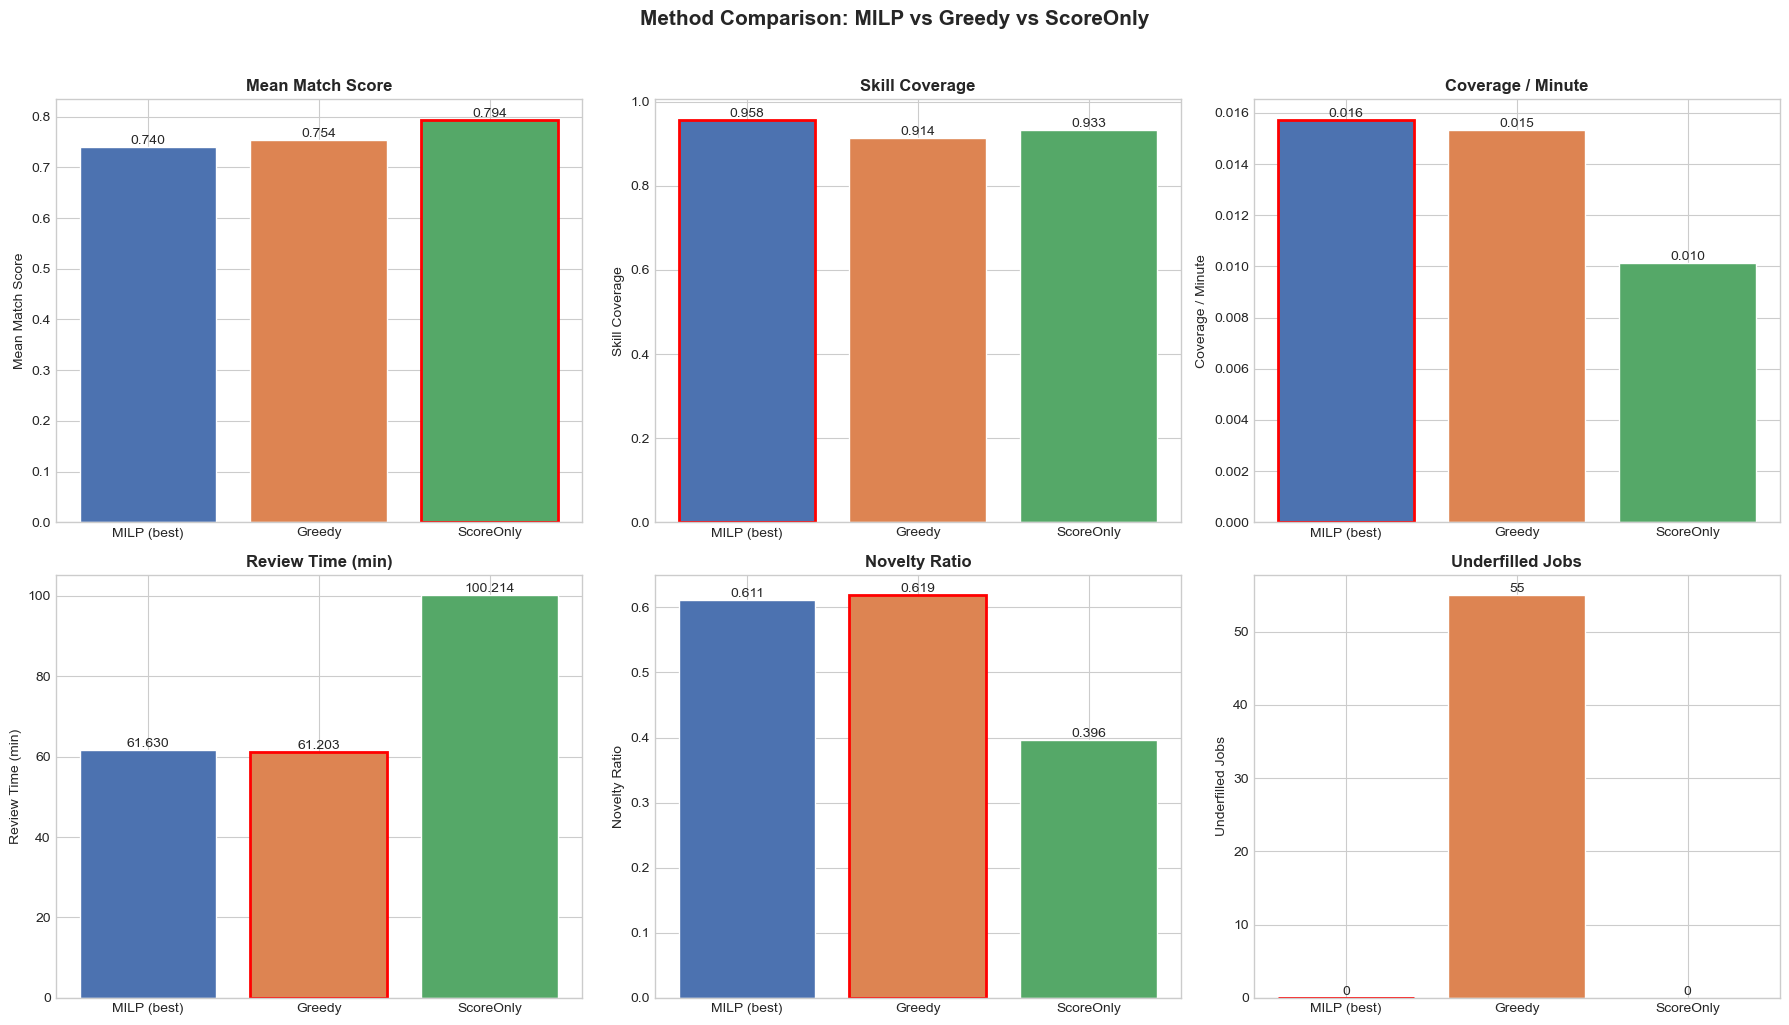

In [27]:
metrics_to_plot = [
    ("mean_match_score", "Mean Match Score", True),
    ("mean_coverage", "Skill Coverage", True),
    ("mean_cov_per_min", "Coverage / Minute", True),
    ("mean_review_min", "Review Time (min)", False),
    ("novelty_ratio", "Novelty Ratio", True),
    ("underfilled_jobs", "Underfilled Jobs", False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {"MILP (best)": "#4C72B0", "Greedy": "#DD8452", "ScoreOnly": "#55A868"}

for ax, (metric, title, higher_better) in zip(axes.flat, metrics_to_plot):
    methods = comparison.index.tolist()
    values = comparison[metric].tolist()
    bars = ax.bar(methods, values, color=[colors.get(m, "gray") for m in methods], edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.set_ylabel(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.3f}" if isinstance(val, float) else str(val),
                ha="center", va="bottom", fontsize=10)
    best_idx = values.index(max(values)) if higher_better else values.index(min(values))
    bars[best_idx].set_edgecolor("red"); bars[best_idx].set_linewidth(2)

fig.suptitle("Method Comparison: MILP vs Greedy vs ScoreOnly", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(OUT_DIR / "01_method_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.3 Sweep Results

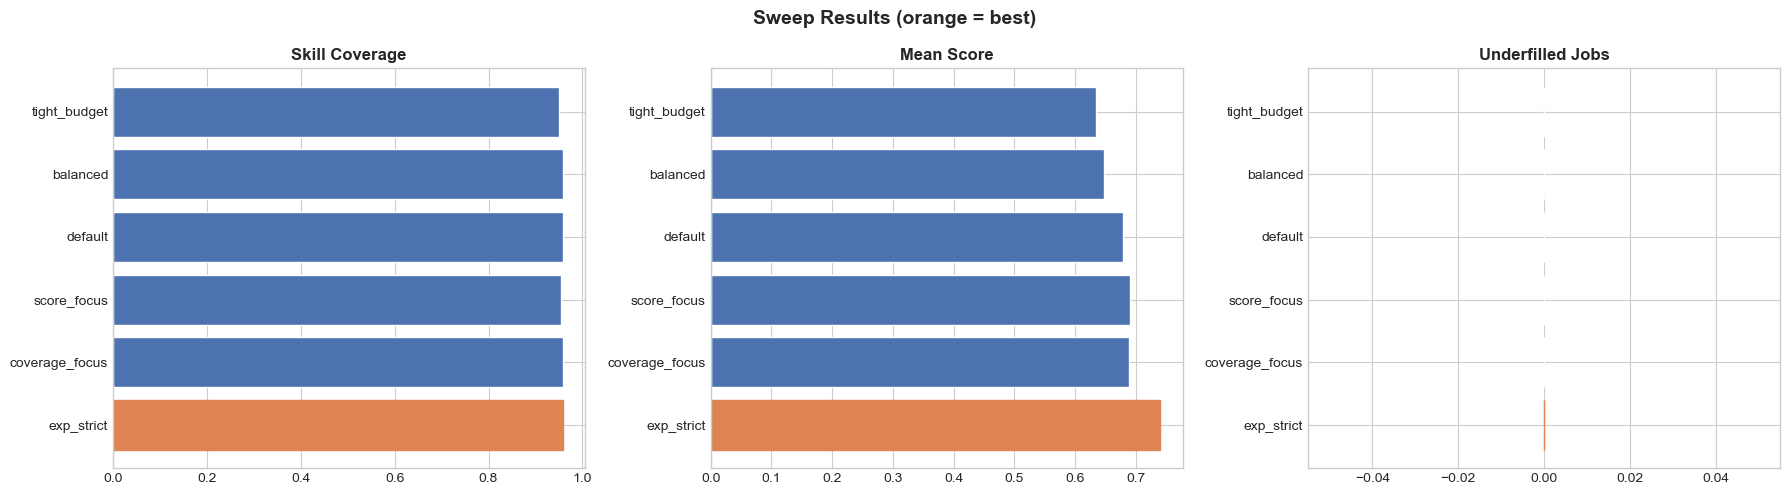

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sp = sweep_df.sort_values("meta_score", ascending=False)

for ax, (metric, title) in zip(axes, [
    ("mean_coverage", "Skill Coverage"), ("mean_match_score", "Mean Score"),
    ("underfilled_jobs", "Underfilled Jobs")
]):
    bars = ax.barh(sp["config"], sp[metric], color="#4C72B0", edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    best_idx = list(sp["config"]).index(best_name)
    bars[best_idx].set_color("#DD8452")

fig.suptitle("Sweep Results (orange = best)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "02_sweep_results.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.4 Per-Job Breakdown

In [31]:
if best_milp["selected"]:
    sel_df = pd.DataFrame(best_milp["selected"], columns=["resume_id", "job_id"])
    sel_df = sel_df.merge(pair_df, on=["resume_id", "job_id"], how="left")

    job_summary = []
    for j in ALL_JOBS:
        js = sel_df[sel_df["job_id"] == j]
        title = job_df.loc[job_df["job_id"] == j, "job_title"].iloc[0]
        req = set(job_df.loc[job_df["job_id"] == j, "required_skills"].iloc[0])
        covered = set()
        for _, row in js.iterrows():
            r_sk = set(resume_df.loc[resume_df["resume_id"] == int(row["resume_id"]), "skill_set"].iloc[0])
            covered |= (r_sk & req)

        scores = [pair_quality(int(row["resume_id"]), j, BEST_CONFIG) for _, row in js.iterrows()] if len(js) > 0 else [0]

        job_summary.append({
            "job_id": j, "title": title, "selected": len(js),
            "mean_score": np.mean(scores),
            "coverage": len(covered) / max(len(req), 1),
            "review_min": js["review_minutes_capped"].sum() if len(js) > 0 else 0,
        })

    jsdf = pd.DataFrame(job_summary)
    print(f"Full shortlists: {(jsdf['selected'] == K_SHORTLIST).sum()} / {len(ALL_JOBS)}")
    print(f"Underfilled:     {(jsdf['selected'] < K_SHORTLIST).sum()}")
    print(f"Mean score:      {jsdf['mean_score'].mean():.3f}")
    print(f"Mean coverage:   {jsdf['coverage'].mean():.3f}")
    display(jsdf.head(15))

Full shortlists: 90 / 90
Underfilled:     0
Mean score:      0.740
Mean coverage:   0.958


,job_id,title,selected,mean_score,coverage,review_min
0,0,Backend Developer,5,0.7543,1.0000,62.0195
1,1,Backend Developer,5,0.7563,1.0000,61.5940
2,2,Backend Developer,5,0.7675,1.0000,63.5375
3,3,Backend Developer,5,0.7286,1.0000,59.7310
4,4,Backend Developer,5,0.7456,1.0000,62.9050
5,5,Backend Developer,5,0.6368,1.0000,64.3310
6,6,Database Administrator,5,0.8121,1.0000,64.5265
7,7,Database Administrator,5,0.6901,1.0000,63.1465
8,8,Database Administrator,5,0.8558,1.0000,63.5605
9,9,Database Administrator,5,0.7973,1.0000,62.6175


### 8.5 Decision Diagnostics & Case Extraction

In [33]:
def shorten_text(text, n=400):
    if not isinstance(text, str):
        return ""
    text = " ".join(text.split())
    return text[:n] + ("..." if len(text) > n else "")


resume_skill_lookup = {
    int(r["resume_id"]): set(r["skill_set"])
    for _, r in resume_df.iterrows()
}

job_req_lookup = {
    int(r["job_id"]): set(r["required_skills"])
    for _, r in job_df.iterrows()
}

job_title_lookup = {
    int(r["job_id"]): r["job_title"]
    for _, r in job_df.iterrows()
}


def covered_required_skills(resume_ids, req_skills):
    covered = set()
    for rid in resume_ids:
        covered |= (resume_skill_lookup[int(rid)] & set(req_skills))
    return covered


def build_decision_outputs(best_result, config, budget, k=K_SHORTLIST):
    x_df = best_result["x_df"].copy()

    # ── Resume metadata ──
    resume_cols = ["resume_id", "skill_set", "review_minutes_capped", "redundancy_cluster",
                   "word_count", "exp_years", "degree_level"]
    for c in ["text_raw", "text_clean"]:
        if c in resume_df.columns:
            resume_cols.append(c)

    resume_meta = resume_df[resume_cols].copy().rename(columns={
        "skill_set": "resume_skill_set",
        "review_minutes_capped": "resume_review_minutes",
        "redundancy_cluster": "resume_redundancy_cluster",
        "word_count": "resume_word_count_meta",
        "exp_years": "resume_exp_years_meta",
        "degree_level": "resume_degree_level_meta",
        "text_raw": "resume_text_raw",
        "text_clean": "resume_text_clean",
    })

    # ── Job metadata ──
    job_cols = ["job_id", "job_title", "required_skills", "skill_set",
                "exp_years", "degree_level"]
    for c in ["text_raw", "text_clean"]:
        if c in job_df.columns:
            job_cols.append(c)

    job_meta = job_df[job_cols].copy().rename(columns={
        "skill_set": "job_skill_set",
        "required_skills": "job_required_skills",
        "exp_years": "job_required_exp_meta",
        "degree_level": "job_required_degree_meta",
        "text_raw": "job_text_raw",
        "text_clean": "job_text_clean",
    })

    # ── Main pair-level table (all 45k pairs, still manageable) ──
    pair_detail = (
        x_df
        .merge(pair_df, on=["resume_id", "job_id"], how="left")
        .merge(
            norm_df[
                ["resume_id", "job_id",
                 "tfidf_sim_norm", "bm25_sim_norm", "skill_overlap_jaccard_norm",
                 "weighted_required_hit_norm", "exp_gap_norm", "degree_gap_norm",
                 "length_penalty_norm"]
            ],
            on=["resume_id", "job_id"],
            how="left"
        )
        .merge(resume_meta, on="resume_id", how="left")
        .merge(job_meta, on="job_id", how="left")
    )

    # ── Snippets for quick viewing ──
    if "resume_text_raw" in pair_detail.columns:
        pair_detail["resume_text_snippet"] = pair_detail["resume_text_raw"].apply(lambda x: shorten_text(x, 350))
    else:
        pair_detail["resume_text_snippet"] = ""

    if "job_text_raw" in pair_detail.columns:
        pair_detail["job_text_snippet"] = pair_detail["job_text_raw"].apply(lambda x: shorten_text(x, 350))
    else:
        pair_detail["job_text_snippet"] = ""

    # ── Ranking / top-k comparison ──
    pair_detail["score_rank_within_job"] = (
        pair_detail.groupby("job_id")["pair_quality"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    pair_detail["topk_by_score"] = (pair_detail["score_rank_within_job"] <= k).astype(int)
    pair_detail["excluded_despite_topk_score"] = (
        (pair_detail["topk_by_score"] == 1) & (pair_detail["selected"] == 0)
    ).astype(int)
    pair_detail["selected_beyond_topk_score"] = (
        (pair_detail["topk_by_score"] == 0) & (pair_detail["selected"] == 1)
    ).astype(int)

    # ── Skills comparison ──
    pair_detail["matched_required_skills"] = pair_detail.apply(
        lambda r: sorted(set(r["resume_skill_set"]) & set(r["job_required_skills"])),
        axis=1
    )

    pair_detail["missing_required_skills"] = pair_detail.apply(
        lambda r: sorted(set(r["job_required_skills"]) - set(r["resume_skill_set"])),
        axis=1
    )

    pair_detail["extra_resume_skills"] = pair_detail.apply(
        lambda r: sorted(set(r["resume_skill_set"]) - set(r["job_required_skills"])),
        axis=1
    )

    # ── Signal contributions to final score ──
    pair_detail["contrib_tfidf"] = config["w_tfidf"] * pair_detail["tfidf_sim_norm"]
    pair_detail["contrib_bm25"] = config["w_bm25"] * pair_detail["bm25_sim_norm"]
    pair_detail["contrib_skill"] = config["w_skill"] * pair_detail["skill_overlap_jaccard_norm"]
    pair_detail["contrib_coverage"] = config["w_coverage"] * pair_detail["weighted_required_hit_norm"]
    pair_detail["contrib_exp"] = config["w_exp"] * pair_detail["exp_gap_norm"]
    pair_detail["contrib_deg"] = config["w_deg"] * pair_detail["degree_gap_norm"]
    pair_detail["contrib_length"] = config["w_length"] * pair_detail["length_penalty_norm"]

    def membership_label(row):
        if row["selected"] == 1 and row["topk_by_score"] == 1:
            return "selected_and_topk"
        if row["selected"] == 1 and row["topk_by_score"] == 0:
            return "selected_not_topk"
        if row["selected"] == 0 and row["topk_by_score"] == 1:
            return "topk_not_selected"
        return "other"

    pair_detail["selection_membership"] = pair_detail.apply(membership_label, axis=1)

    def reason_tag(row):
        if row["selection_membership"] == "selected_not_topk":
            if len(row["matched_required_skills"]) > 0:
                return "selected_for_coverage_or_feasibility"
            return "selected_beyond_topk"
        if row["selection_membership"] == "topk_not_selected":
            return "high_score_excluded_by_constraints"
        if row["selection_membership"] == "selected_and_topk":
            return "normal_topk_selection"
        return "not_selected"

    pair_detail["reason_tag"] = pair_detail.apply(reason_tag, axis=1)

    # ── Job-level diagnostics ──
    job_rows = []

    for j in ALL_JOBS:
        g = pair_detail[pair_detail["job_id"] == j].copy().sort_values("pair_quality", ascending=False)

        selected_ids = g.loc[g["selected"] == 1, "resume_id"].tolist()
        topk_ids = g.head(k)["resume_id"].tolist()

        req_skills = job_req_lookup[j]
        selected_cov = covered_required_skills(selected_ids, req_skills)
        topk_cov = covered_required_skills(topk_ids, req_skills)

        budget_used = g.loc[g["selected"] == 1, "resume_review_minutes"].sum()
        budget_slack = budget - budget_used
        budget_util = budget_used / budget if budget > 0 else np.nan

        excluded_ids = g.loc[(g["topk_by_score"] == 1) & (g["selected"] == 0), "resume_id"].tolist()
        selected_beyond_ids = g.loc[(g["selected"] == 1) & (g["topk_by_score"] == 0), "resume_id"].tolist()

        high_score_not_selected = int(len(excluded_ids) > 0)            # Case A
        time_budget_tight = int(budget_util >= 0.95)                    # Case B
        skill_tradeoff = int((set(selected_ids) != set(topk_ids)) and (len(selected_cov) > len(topk_cov)))  # Case C
        selected_equals_topk = int(set(selected_ids) == set(topk_ids))

        if selected_equals_topk == 1 and time_budget_tight == 0 and skill_tradeoff == 0:
            case_explanation = "MILP selected essentially the same set as simple top-k score ranking."
        elif high_score_not_selected == 1:
            case_explanation = "At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."
        elif time_budget_tight == 1:
            case_explanation = "The time budget is binding or near-binding, so review time actively shapes the shortlist."
        elif skill_tradeoff == 1:
            case_explanation = "MILP selected a lower-scoring combination to improve collective required-skill coverage."
        else:
            case_explanation = "Selection differs from simple top-k in a less obvious way."

        job_rows.append({
            "job_id": j,
            "job_title": job_title_lookup[j],
            "job_text_snippet": shorten_text(g["job_text_raw"].iloc[0] if "job_text_raw" in g.columns and len(g) else "", 500),
            "job_text_raw": g["job_text_raw"].iloc[0] if "job_text_raw" in g.columns and len(g) else "",
            "required_skills": sorted(list(req_skills)),
            "selected_count": int(g["selected"].sum()),
            "mean_selected_score": float(g.loc[g["selected"] == 1, "pair_quality"].mean()) if (g["selected"] == 1).any() else 0.0,
            "budget_used": float(budget_used),
            "budget_slack": float(budget_slack),
            "budget_utilisation": float(budget_util),
            "selected_coverage": len(selected_cov) / max(len(req_skills), 1),
            "topk_score_coverage": len(topk_cov) / max(len(req_skills), 1),
            "coverage_gain_vs_topk": (len(selected_cov) - len(topk_cov)) / max(len(req_skills), 1),
            "selected_resume_ids": selected_ids,
            "topk_score_resume_ids": topk_ids,
            "excluded_topk_resume_ids": excluded_ids,
            "selected_beyond_topk_resume_ids": selected_beyond_ids,
            "selected_covered_skills": sorted(list(selected_cov)),
            "topk_score_covered_skills": sorted(list(topk_cov)),
            "selected_missing_required_skills": sorted(list(req_skills - selected_cov)),
            "topk_missing_required_skills": sorted(list(req_skills - topk_cov)),
            "high_score_not_selected": high_score_not_selected,
            "time_budget_tight": time_budget_tight,
            "skill_tradeoff": skill_tradeoff,
            "selected_equals_topk": selected_equals_topk,
            "case_explanation": case_explanation,
        })

    job_diag = pd.DataFrame(job_rows)

    # ── Pick distinct case jobs ──
    chosen = set()

    def pick_one(df, mask, sort_cols, ascending):
        cand = df[mask & (~df["job_id"].isin(chosen))].sort_values(sort_cols, ascending=ascending).head(1)
        if len(cand):
            chosen.add(int(cand["job_id"].iloc[0]))
        return cand

    normal_job = pick_one(
        job_diag,
        (job_diag["selected_equals_topk"] == 1) &
        (job_diag["time_budget_tight"] == 0) &
        (job_diag["skill_tradeoff"] == 0),
        ["mean_selected_score"],
        [False]
    )

    case_A = pick_one(
        job_diag,
        (job_diag["high_score_not_selected"] == 1),
        ["budget_utilisation", "mean_selected_score"],
        [False, False]
    )

    case_B = pick_one(
        job_diag,
        (job_diag["time_budget_tight"] == 1),
        ["budget_utilisation", "mean_selected_score"],
        [False, False]
    )

    case_C = pick_one(
        job_diag,
        (job_diag["skill_tradeoff"] == 1),
        ["coverage_gain_vs_topk", "mean_selected_score"],
        [False, False]
    )

    case_jobs = []
    if len(normal_job):
        case_jobs.append(normal_job.assign(case_type="normal", case_label="Normal job"))
    if len(case_A):
        case_jobs.append(case_A.assign(case_type="A_high_score_not_selected", case_label="Case A: high-score candidate excluded"))
    if len(case_B):
        case_jobs.append(case_B.assign(case_type="B_time_budget_tight", case_label="Case B: time budget tight"))
    if len(case_C):
        case_jobs.append(case_C.assign(case_type="C_skill_tradeoff", case_label="Case C: skill coverage trade-off"))

    case_jobs_df = pd.concat(case_jobs, ignore_index=True) if case_jobs else pd.DataFrame()

    # ── Rich candidate-level case table for presentation ──
    case_job_ids = case_jobs_df["job_id"].tolist() if len(case_jobs_df) else []

    case_pairs_df = pair_detail[pair_detail["job_id"].isin(case_job_ids)].copy() if len(case_job_ids) else pd.DataFrame()

    if len(case_pairs_df):
        # keep only candidates relevant for comparison in presentation
        case_pairs_df = case_pairs_df[
            (case_pairs_df["selected"] == 1) | (case_pairs_df["topk_by_score"] == 1)
        ].copy()

        case_pairs_df = case_pairs_df.merge(
            case_jobs_df[["job_id", "case_type", "case_label"]],
            on="job_id",
            how="left"
        )

        case_pairs_df["case_role"] = case_pairs_df["selection_membership"]

        case_pairs_df["resume_text_full"] = case_pairs_df["resume_text_raw"]
        case_pairs_df["job_text_full"] = case_pairs_df["job_text_raw"]

        case_pairs_df["resume_text_snippet"] = case_pairs_df["resume_text_full"].apply(lambda x: shorten_text(x, 500))
        case_pairs_df["job_text_snippet"] = case_pairs_df["job_text_full"].apply(lambda x: shorten_text(x, 500))

        role_order = {
            "selected_and_topk": 1,
            "selected_not_topk": 2,
            "topk_not_selected": 3,
            "other": 4,
        }
        case_pairs_df["case_role_order"] = case_pairs_df["case_role"].map(role_order).fillna(99)

        case_pairs_df = case_pairs_df.sort_values(
            ["case_type", "job_id", "case_role_order", "score_rank_within_job"],
            ascending=[True, True, True, True]
        )

    return pair_detail, job_diag, case_jobs_df, case_pairs_df

In [34]:
pair_detail_df, job_diag_df, case_jobs_df, case_pairs_df = build_decision_outputs(
    best_milp, BEST_CONFIG, BEST_BUDGET, k=K_SHORTLIST
)

display(job_diag_df.head())
display(case_jobs_df)
display(case_pairs_df.head(20))

,job_id,job_title,job_text_snippet,job_text_raw,required_skills,selected_count,mean_selected_score,budget_used,budget_slack,budget_utilisation,...,selected_beyond_topk_resume_ids,selected_covered_skills,topk_score_covered_skills,selected_missing_required_skills,topk_missing_required_skills,high_score_not_selected,time_budget_tight,skill_tradeoff,selected_equals_topk,case_explanation
0,0,Backend Developer,Looking for the most motivated Backend developer who have experience in building Api's to develop an Api for the web...,Looking for the most motivated Backend developer who have experience in building Api's to develop an Api for the web...,"[docker, laravel, mongodb, node.js, postgresql]",5,0.7543,62.0195,2.9805,0.9541,...,"[304, 299, 494]","[docker, laravel, mongodb, node.js, postgresql]","[docker, mongodb, node.js, postgresql]",[],[laravel],1,1,1,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."
1,1,Backend Developer,"Basic Info Location Bangalore, Karnataka, India Job type Full-Time Contract Regular/Permanent Take the next step in ...","Basic Info\nLocation\nBangalore, Karnataka, India\nJob type\nFull-Time\nContract\nRegular/Permanent\nTake the next s...","[bootstrap, devops, sql server, testing, typescript]",5,0.7563,61.5940,3.4060,0.9476,...,"[264, 108]","[bootstrap, devops, sql server, testing, typescript]","[bootstrap, devops, sql server, testing, typescript]",[],[],1,0,0,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."
2,2,Backend Developer,Job Title: Senior Backend Developer (RoR) We are an outsourcing company working for clients based around the world. ...,Job Title: Senior Backend Developer (RoR)\nWe are an outsourcing company working for clients based around the world....,"[agile, api, rail, rest, ruby]",5,0.7675,63.5375,1.4625,0.9775,...,"[412, 383, 21]","[agile, api, rail, rest, ruby]","[agile, api, rail, rest, ruby]",[],[],1,1,0,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."
3,3,Backend Developer,We are looking to hire an Angular developer who can contribute to building and scaling our product and internal appl...,We are looking to hire an Angular developer who can contribute to building and scaling our product and internal appl...,"[angular, css, docker, git, html]",5,0.7286,59.7310,5.2690,0.9189,...,"[93, 124]","[angular, css, docker, git, html]","[angular, css, docker, git, html]",[],[],1,0,0,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."
4,4,Backend Developer,Experience range - 2 - 5 Yrs experience Salary Range - 15 - 25 Lakhs Notice Period - Less than 30 days. Tech Stack -...,Experience range - 2 - 5 Yrs experience\nSalary Range - 15 - 25 Lakhs\nNotice Period - Less than 30 days.\nTech Stac...,"[kafka, leadership, mongodb, problem solving, spring]",5,0.7456,62.9050,2.0950,0.9678,...,"[404, 490, 487]","[kafka, leadership, mongodb, problem solving, spring]","[kafka, leadership, mongodb, problem solving, spring]",[],[],1,1,0,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off."


,job_id,job_title,job_text_snippet,job_text_raw,required_skills,selected_count,mean_selected_score,budget_used,budget_slack,budget_utilisation,...,topk_score_covered_skills,selected_missing_required_skills,topk_missing_required_skills,high_score_not_selected,time_budget_tight,skill_tradeoff,selected_equals_topk,case_explanation,case_type,case_label
0,20,Django Developer,Job Responsibilities : - Lead a team of Python analytics and application developers - Be responsible for Analytics a...,Job Responsibilities :\n- Lead a team of Python analytics and application developers\n- Be responsible for Analytics...,"[django, excel, python, sql]",5,0.7039,56.7295,8.2705,0.8728,...,"[django, excel, python, sql]",[],[],0,0,0,1,MILP selected essentially the same set as simple top-k score ranking.,normal,Normal job
1,42,JavaScript Developer,"Software Engineer Who are we? Every day, billions of transactions, calls and messages that hold the world’s communic...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...","[angular, iot, jenkins, react, typescript]",5,0.7818,64.9980,0.0020,1.0000,...,"[angular, jenkins, react, typescript]",[],[iot],1,1,1,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off.",A_high_score_not_selected,Case A: high-score candidate excluded
2,64,Node js developer,Location: Pune Experience: 3+ years Requirements: • Strong Hands-on Experience on NodeJS. • Hands-on experience in w...,Location: Pune\n\nExperience: 3+ years\n\nRequirements:\n\n• Strong Hands-on Experience on NodeJS.\n\n• Hands-on exp...,"[bootstrap, express, postgresql, sqlite, typescript]",5,0.7874,64.9175,0.0825,0.9987,...,"[bootstrap, express, postgresql, typescript]",[],[sqlite],1,1,1,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off.",B_time_budget_tight,Case B: time budget tight
3,49,Machine Learning,"Company: Qualcomm India Private Limited Job Area: Engineering Group, Engineering Group > Machine Learning Engineerin...","Company:\nQualcomm India Private Limited\nJob Area:\nEngineering Group, Engineering Group > Machine Learning Enginee...","[communication, cs, machine learning, testing]",5,0.5567,64.8186,0.1814,0.9972,...,"[communication, machine learning, testing]",[],[cs],1,1,1,0,"At least one high-score candidate was excluded, indicating a constraint-driven selection trade-off.",C_skill_tradeoff,Case C: skill coverage trade-off


,resume_id,job_id,x_value,selected,pair_quality,review_minutes,redundancy_cluster_x,job_title_x,tfidf_sim,bm25_sim,...,contrib_deg,contrib_length,selection_membership,reason_tag,case_type,case_label,case_role,resume_text_full,job_text_full,case_role_order
13,260,42,1.0000,1,0.9150,17.9170,159,JavaScript Developer,0.0784,0.9109,...,0.1000,0.0471,selected_and_topk,normal_topk_selection,A_high_score_not_selected,Case A: high-score candidate excluded,selected_and_topk,"Frontend Developer Frontend <span class=""hl"">Developer</span> Frontend Developer - Verizon Media Santa Clara, CA ? 8...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",1
12,253,42,1.0000,1,0.8514,19.7570,114,JavaScript Developer,0.0637,0.7263,...,0.1000,0.0464,selected_and_topk,normal_topk_selection,A_high_score_not_selected,Case A: high-score candidate excluded,selected_and_topk,"UI Developer UI <span class=""hl"">Developer</span> UI Developer - Department of Transportation (MA) Scottsdale, AZ • ...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",1
27,488,42,1.0000,1,0.7945,11.6610,186,JavaScript Developer,0.0689,0.7476,...,0.1000,0.0493,selected_not_topk,selected_for_coverage_or_feasibility,A_high_score_not_selected,Case A: high-score candidate excluded,selected_not_topk,Software Development Engineer Software Development Engineer Software Development Engineer - Deutsche Bank Morrisvill...,"Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",2
25,468,42,1.0000,1,0.7400,9.6715,155,JavaScript Developer,0.0623,0.6072,...,0.1000,0.0499,selected_not_topk,selected_for_coverage_or_feasibility,A_high_score_not_selected,Case A: high-score candidate excluded,selected_not_topk,"Web Developer Web <span class=""hl"">Developer</span> Web Developer - Upwork California City, CA • 3.5+ Years of exper...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",2
16,310,42,1.0000,1,0.6080,5.9915,71,JavaScript Developer,0.0407,0.4036,...,0.0500,0.0486,selected_not_topk,selected_for_coverage_or_feasibility,A_high_score_not_selected,Case A: high-score candidate excluded,selected_not_topk,"Team Lead - Front End Web Developer Team Lead - <span class=""hl"">Front</span> <span class=""hl"">End</span> Web <span ...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",2
21,409,42,-0.0000,0,0.8668,31.5100,145,JavaScript Developer,0.0668,0.9014,...,0.1000,0.0421,topk_not_selected,high_score_excluded_by_constraints,A_high_score_not_selected,Case A: high-score candidate excluded,topk_not_selected,"Front-End Developer Front-End <span class=""hl"">Developer</span> Front-End Developer - CSX Technology, Jacksonville J...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",3
19,388,42,0.0000,0,0.8597,22.6895,146,JavaScript Developer,0.0604,0.7402,...,0.1000,0.0453,topk_not_selected,high_score_excluded_by_constraints,A_high_score_not_selected,Case A: high-score candidate excluded,topk_not_selected,"Developer <span class=""hl"">Developer</span> Developer - Teleflora, OK Jersey City, NJ ? Over 6+years of extensive ex...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the world’s commun...",3
0,34,42,0.0000,0,0.8525,24.9320,158,JavaScript Developer,0.0821,0.9157,...,0.1000,0.0445,topk_not_selected,high_score_excluded_by_constraints,A_high_score_not_selected,Case A: high-score candidate excluded,topk_not_selected,"Senior Full Stack Developer Senior Full Stack <span class=""hl"">Developer</span> Senior Full Stack Developer - Capita...","Software Engineer\nWho are we?\nEvery day, billions of transactions, calls and messages that hold the

## 9. Save Results

In [36]:
comparison.to_csv(OUT_DIR / "method_comparison.csv")
sweep_df.to_csv(OUT_DIR / "sweep_results.csv", index=False)

if best_milp["selected"]:
    pd.DataFrame(best_milp["selected"], columns=["resume_id","job_id"]).to_csv(
        OUT_DIR / "milp_best_selected.csv", index=False)

if "x_df" in best_milp:
    best_milp["x_df"].to_csv(OUT_DIR / "milp_x_values.csv", index=False)
    best_milp["u_df"].to_csv(OUT_DIR / "milp_u_values.csv", index=False)
    best_milp["q_df"].to_csv(OUT_DIR / "milp_q_values.csv", index=False)
    best_milp["y_df"].to_csv(OUT_DIR / "milp_y_values.csv", index=False)

pair_detail_df.to_csv(OUT_DIR / "milp_pair_decisions_detailed.csv", index=False)
job_diag_df.to_csv(OUT_DIR / "milp_job_diagnostics.csv", index=False)
case_jobs_df.to_csv(OUT_DIR / "milp_case_jobs.csv", index=False)
case_pairs_df.to_csv(OUT_DIR / "milp_case_pairs.csv", index=False)

pd.DataFrame(greedy_best, columns=["resume_id","job_id"]).to_csv(OUT_DIR / "greedy_selected.csv", index=False)
pd.DataFrame(scoreonly_best, columns=["resume_id","job_id"]).to_csv(OUT_DIR / "scoreonly_selected.csv", index=False)

with open(OUT_DIR / "best_config.json", "w") as f:
    json.dump({"name": best_name, "config": BEST_CONFIG,
               "budget": BEST_BUDGET, "floor": BEST_FLOOR}, f, indent=2)

## 10. Parameter Summary

### Why Per-Job Normalisation Fixes the Score Problem

| Before (raw) | After (normalised) |
|---|---|
| TF-IDF: 0–0.21 | TF-IDF_norm: 0–1.0 per job |
| BM25: 0–1.0 | BM25_norm: 0–1.0 per job |
| Skill Jaccard: 0–1.0 | Skill_norm: 0–1.0 per job |
| exp_gap: 0–9 years | exp_match_norm: 0–1.0 (inverted) |
| degree_gap: 0–4 levels | deg_match_norm: 0–1.0 (inverted) |

After normalisation, a composite score of 0.80 means *"this candidate is at the 80th percentile across all signals for this job"* — directly interpretable.

### Structural Constraints
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `K_SHORTLIST` | 5 | Standard tech hiring shortlist |
| `MAX_CANDIDATE_JOBS` | 2 | Prevents monopolisation |
| `REVIEW_BUDGET_MIN` | 65 | ~13 min/resume × 5; median from NB1 |
| `MIN_AVG_SCORE_FLOOR` | 0.40 | On normalised 0–1 scale |
| `GUROBI_MIP_GAP` | 0.1% | Early termination when near-optimal |

---

**Next → Notebook 3**: Sensitivity analysis on budget, shortlist size, exposure cap.